In [2]:
## Practice 1:

import numpy as np
import matplotlib.pyplot  as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist

In [3]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

print("Training Shape: ",X_train.shape)
print("Test Shape: ",X_test.shape)

Training Shape:  (60000, 28, 28)
Test Shape:  (10000, 28, 28)


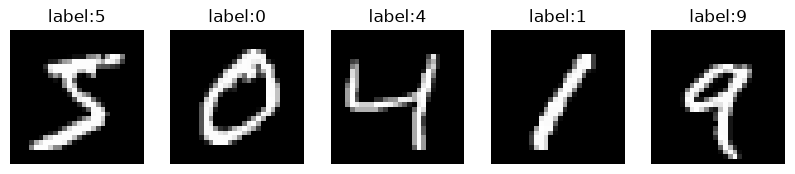

In [8]:

plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i],cmap="gray")
    plt.title(f"label:{y_train[i]}")
    plt.axis("off")

plt.show()

In [10]:
## Practice 2:

X_train=X_train.astype("float32")/255.0
X_test=X_test.astype("float32")/255.0

In [11]:
X_train=X_train.reshape(-1,784)
X_test=X_test.reshape(-1,784)

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [15]:
from tensorflow import keras
from tensorflow.keras import layers

model=keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128,activation="relu"),
    layers.Dense(64,activation="relu"),
    layers.Dense(10,activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history=model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

test_loss,test_accuracy=model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy: ",test_accuracy)

    

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8992 - loss: 0.3630 - val_accuracy: 0.9613 - val_loss: 0.1392
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9566 - loss: 0.1468 - val_accuracy: 0.9698 - val_loss: 0.1053
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9704 - loss: 0.0997 - val_accuracy: 0.9723 - val_loss: 0.0973
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9783 - loss: 0.0738 - val_accuracy: 0.9783 - val_loss: 0.0832
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9821 - loss: 0.0597 - val_accuracy: 0.9720 - val_loss: 0.1001
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9854 - loss: 0.0481 - val_accuracy: 0.9782 - val_loss: 0.0801
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9883 - loss: 0.0391 - val_accuracy: 0.9785 - val_loss: 0.0750
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9904 - loss: 0.0326 - val_accuracy: 0.

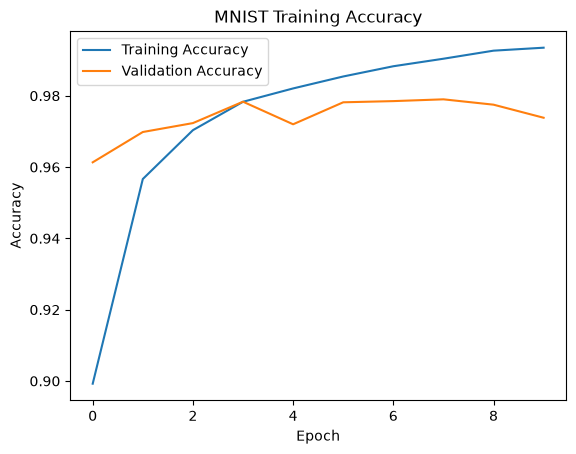

In [16]:
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST Training Accuracy")
plt.legend()
plt.show()



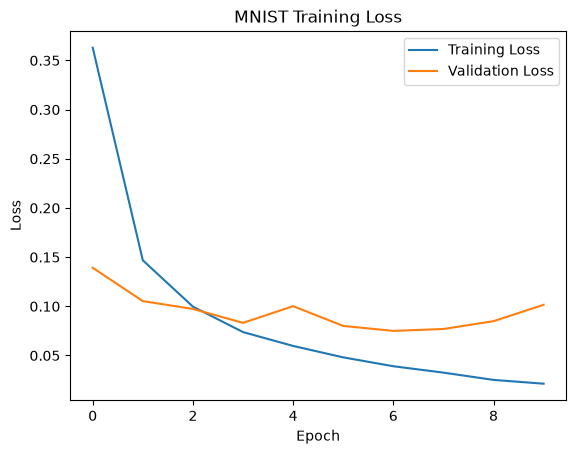

In [17]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Training Loss")
plt.legend()
plt.show()

In [18]:
y_prob=model.predict(X_test)

y_pred=np.argmax(y_prob,axis=1)

print(y_pred[:10])
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


In [19]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)

print(cm)



[[ 970    0    1    3    2    1    1    1    1    0]
 [   0 1122    2    7    0    1    2    0    1    0]
 [   3    0 1007    9    1    0    2    4    5    1]
 [   0    0    2 1001    0    3    0    1    2    1]
 [   1    0    4    2  952    1    3    1    0   18]
 [   2    0    0   15    0  872    3    0    0    0]
 [   5    2    0    1    6   10  932    1    1    0]
 [   0    4   12   10    0    0    0  997    1    4]
 [   4    0    4   34    0   11    2    2  915    2]
 [   3    2    0   16    2    7    1    2    0  976]]


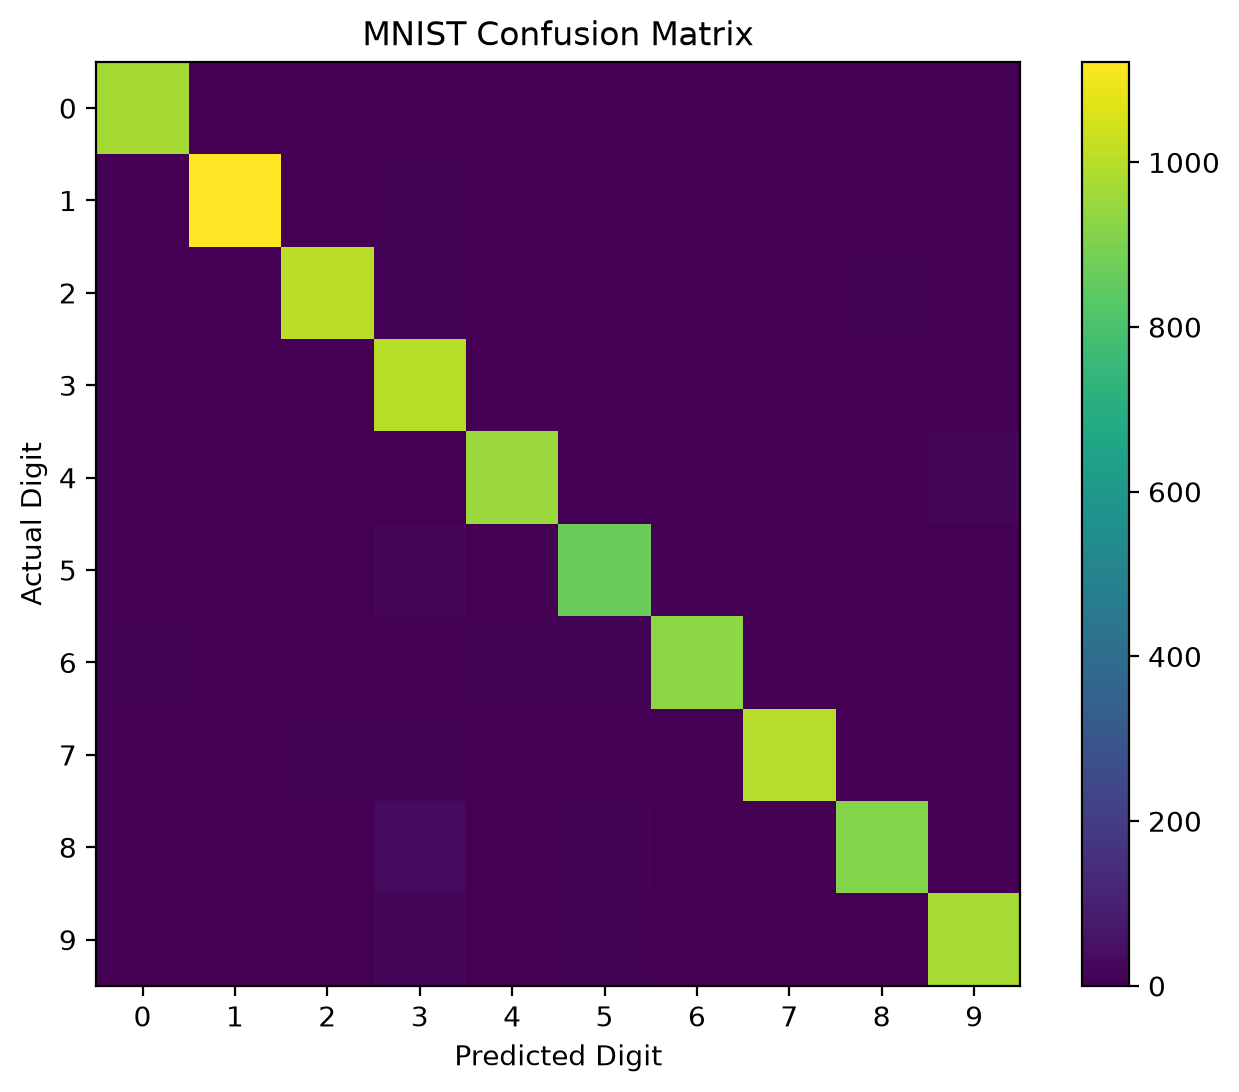

In [20]:
plt.figure(figsize=(8,6),dpi=200)
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("MNIST Confusion Matrix")

plt.show()



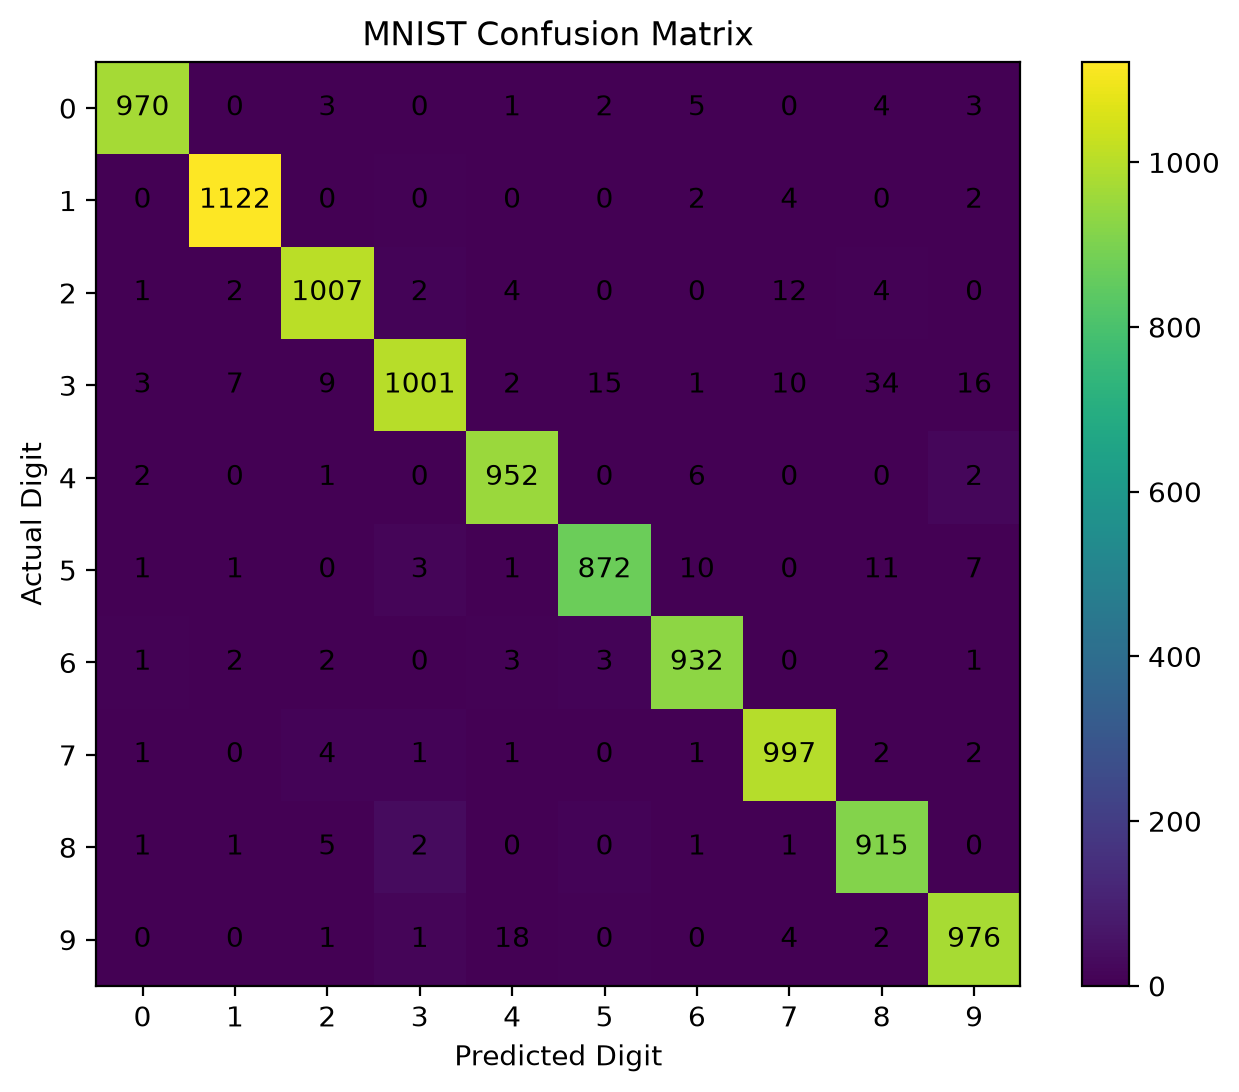

In [23]:
plt.figure(figsize=(8, 6),dpi=200)

plt.imshow(cm)

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))


for i in range(10):
    for j in range(10):
        plt.text(
            i,
            j,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("MNIST Confusion Matrix")

plt.show()

In [25]:
cm_without_diagonal=cm.copy()

np.fill_diagonal(cm_without_diagonal,0)

max_index=np.unravel_index(
    np.argmax(cm_without_diagonal),
    cm_without_diagonal.shape
)

actual_digit= max_index[0]
predicted_digit= max_index[1]

print("Most confused pair: ")
print("Actual: ", actual_digit)
print("Pedicted: ", predicted_digit)
print("Number of Mistakes: ",cm_without_diagonal[max_index])



Most confused pair: 
Actual:  8
Pedicted:  3
Number of Mistakes:  34


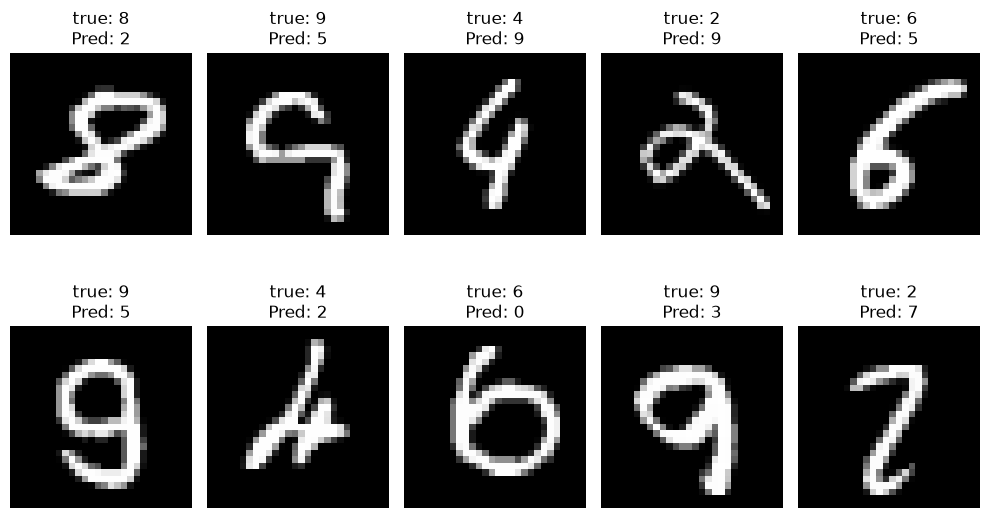

In [26]:
wrong_predictions= np.where(y_pred!=y_test)[0]
plt.figure(figsize=(10,6))

for i in range(10):
    index=wrong_predictions[i]

    plt.subplot(2,5,i+1)
    plt.imshow(X_test[index].reshape(28,28),cmap="gray")
    plt.title(
    f"true: {y_test[index]}\nPred: {y_pred[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()